In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.datasets import make_classification
X,Y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,n_redundant=0,n_classes=2)

In [6]:
X

array([[-0.09303195,  1.32427514],
       [ 1.91895706,  0.83484705],
       [-0.55944283,  0.47510906],
       ...,
       [-2.78473263,  1.03214937],
       [-1.30178951,  0.00389211],
       [-2.31233952, -0.26961121]], shape=(1000, 2))

In [7]:
x0=pd.DataFrame(X)[0]
x1=pd.DataFrame(X)[1]

<Axes: xlabel='0', ylabel='1'>

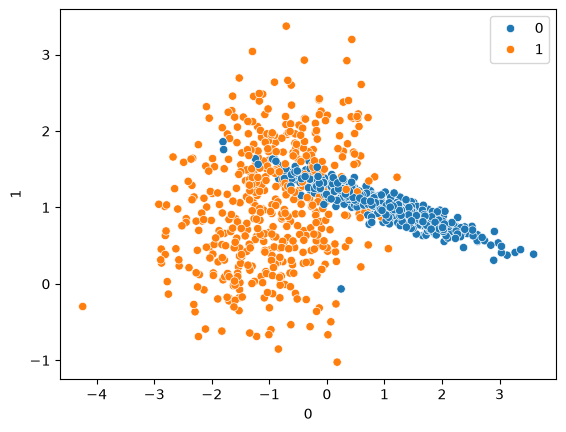

In [8]:
sns.scatterplot(x=x0,y=x1,hue=Y)

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=10)
from sklearn.svm import SVC
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       153
           1       0.90      0.90      0.90       147

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[138  15]
 [ 15 132]]


In [10]:
W,V=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=2,n_redundant=0,n_classes=2)

<Axes: xlabel='0', ylabel='1'>

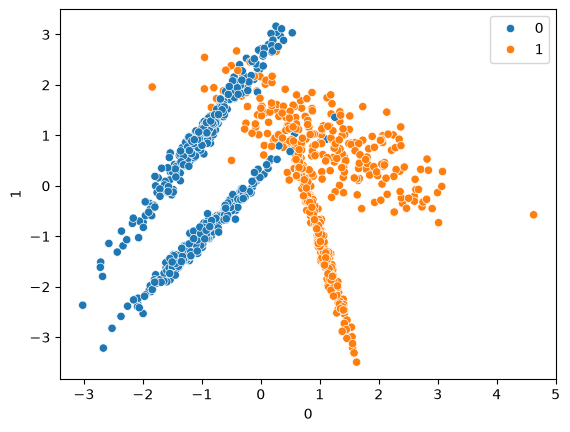

In [11]:
sns.scatterplot(x=pd.DataFrame(W)[0],y=pd.DataFrame(W)[1],hue=V)

In [12]:
W_train,W_test,V_train,V_test=train_test_split(W,V,test_size=0.3,random_state=10)
model=SVC(kernel='rbf')
model.fit(W_train,V_train)
y_pred1=model.predict(W_test)
print(classification_report(V_test,y_pred1))
print(confusion_matrix(V_test,y_pred1))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       159
           1       0.98      0.91      0.95       141

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

[[156   3]
 [ 12 129]]


In [13]:
model1=SVC(kernel='poly')
model1.fit(W_train,V_train)
y_pred2=model1.predict(W_test)
print(classification_report(V_test,y_pred2))
print(confusion_matrix(V_test,y_pred2))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       159
           1       0.89      0.89      0.89       141

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

[[144  15]
 [ 15 126]]


In [14]:
model2=SVC(kernel='linear')
model2.fit(W_train,V_train)
y_pred3=model2.predict(W_test)
print(classification_report(V_test,y_pred3))
print(confusion_matrix(V_test,y_pred3))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93       159
           1       0.98      0.86      0.91       141

    accuracy                           0.92       300
   macro avg       0.93      0.92      0.92       300
weighted avg       0.93      0.92      0.92       300

[[156   3]
 [ 20 121]]


In [15]:
model3=SVC(kernel='sigmoid')
model3.fit(W_train,V_train)
y_pred4=model3.predict(W_test)
print(classification_report(V_test,y_pred4))
print(confusion_matrix(V_test,y_pred4))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       159
           1       0.89      0.82      0.85       141

    accuracy                           0.87       300
   macro avg       0.87      0.86      0.87       300
weighted avg       0.87      0.87      0.87       300

[[144  15]
 [ 25 116]]


In [16]:
params_grid={
    'C':[0.1,1.0,10,100,1000],
    'gamma':[0.001, 0.01, 0.1, 1, 10, 100],
    'kernel':['rbf']
}


In [17]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(SVC(),param_grid=params_grid,cv=5,verbose=3,refit=True,)

In [18]:
grid.fit(W_train,V_train)
y_pred6=grid.predict(W_test)
print(classification_report(V_test,y_pred6))
print(confusion_matrix(V_test,y_pred6))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.514 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.507 total time=   0.0s
[CV 3/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.507 total time=   0.0s
[CV 4/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.507 total time=   0.0s
[CV 5/5] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.507 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.936 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.964 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.950 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.950 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.950 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.929 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

In [19]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'rbf'}

In [20]:
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(8**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])
x1=np.linspace(-5.0,5,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

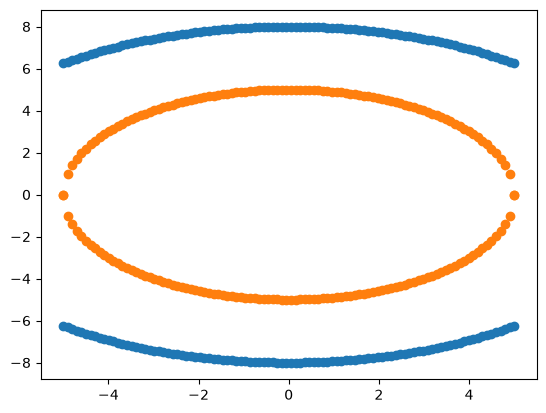

In [21]:
plt.scatter(x,y)
plt.scatter(x1,y1)

In [22]:
df1=pd.DataFrame(np.vstack([x,y]).T,columns=["X1","X2"])
df1['Y']=0
df2=pd.DataFrame(np.vstack([x1,y1]).T,columns=['X1','X2'])
df2['Y']=1
df=pd.concat([df1,df2],ignore_index=True)
df.head()





,X1,X2,Y
0,-5.00000,6.244998,0
1,-4.89899,6.324547,0
2,-4.79798,6.401515,0
3,-4.69697,6.475992,0
4,-4.59596,6.548065,0


In [23]:
df["X1_Squred"]=df['X1']**2
df["X2_Squred"]=df['X2']**2
df['X1.X2']=df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_Squred,X2_Squred,X1.X2
0,-5.00000,6.244998,0,25.000000,39.000000,-31.224990
1,-4.89899,6.324547,0,24.000102,39.999898,-30.983893
2,-4.79798,6.401515,0,23.020610,40.979390,-30.714338
3,-4.69697,6.475992,0,22.061524,41.938476,-30.417539
4,-4.59596,6.548065,0,21.122845,42.877155,-30.094642


In [24]:
import plotly.express as px
fig=px.scatter_3d(df,x="X1",y="X2",z="X1.X2",color='Y')
fig.show()




In [25]:
fig=px.scatter_3d(df,x="X1_Squred",y="X2_Squred",z="X1.X2",color='Y')
fig.show()

In [41]:
X=df[['X1','X2','X1_Squred','X2_Squred','X1.X2']]
Y=df['Y']

In [42]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=10)
X_train


,X1,X2,X1_Squred,X2_Squred,X1.X2
57,0.757576,7.964049,0.573921,63.426079,6.033371
87,3.787879,7.046416,14.348026,49.651974,26.690969
357,-0.757576,-4.942275,0.573921,24.426079,3.744147
355,-0.555556,-4.969040,0.308642,24.691358,2.760578
238,-1.161616,4.863193,1.349352,23.650648,-5.649164
...,...,...,...,...,...
369,-1.969697,-4.595682,3.879706,21.120294,9.052101
320,2.979798,-4.015072,8.879196,16.120804,-11.964104
15,-3.484848,7.201099,12.144169,51.855831,-25.094740
125,2.474747,-7.607603,6.124375,57.875625,-18.826897


In [46]:
svc=SVC(kernel='linear')
svc.fit(X_train,Y_train)
pred=svc.predict(X_test)
print(classification_report(Y_test,pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           1       1.00      1.00      1.00        44

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

